# Data Understanding

Dataset yang dipakai adalah Book-Crossing, hasil crawling komunitas Book-Crossing oleh Cai-Nicolas Ziegler selama empat minggu di tahun 2004. Isinya rating buku dari pengguna asli, ditambah metadata buku dan data demografi.

Link data, https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset

## Memuat data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load the dataset
ratings = pd.read_csv('Ratings.csv', sep=',', encoding='latin-1', on_bad_lines='skip', low_memory=False)
books = pd.read_csv('Books.csv', sep=',', encoding='latin-1', on_bad_lines='skip', low_memory=False)
users = pd.read_csv('Users.csv', sep=',', encoding='latin-1', on_bad_lines='skip', low_memory=False)

print(ratings.shape, books.shape, users.shape)

(1149780, 3) (271360, 8) (278858, 3)


1.149.780 baris rating, 271.360 judul buku, 278.858 pengguna. Tiga berkas terpisah.

`encoding='latin-1'` dipakai karena judul buku mengandung karakter di luar UTF-8, dan `on_bad_lines='skip'` karena ada baris yang rusak format sejak sumber aslinya.

## Kondisi data

In [2]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [3]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


In [4]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


`Ratings` bersih, tidak ada nilai kosong. Di `Books` kekosongannya kecil saja, dua baris `Book-Author`, dua baris `Publisher`, tiga baris `Image-URL-L`.

Yang mencolok `Age` di `Users`, kosong pada 110.762 dari 278.858 baris. Hampir empat puluh persen.

Semua kolom terbaca sebagai object, termasuk `Year-Of-Publication` dan `Age` yang mestinya angka. Berarti ada isi non-numerik yang menyelinap, dan itu perlu ditelusuri.

## Sebaran rating

In [5]:
ratings['Book-Rating'].value_counts().sort_index()

Book-Rating
0     716109
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64

Nilai 0 muncul 716.109 kali, 62 persen dari seluruh baris. Ziegler menyebut 0 sebagai penanda interaksi implisit, bukan penilaian buruk, jadi angka ini tidak sekelas dengan 1 sampai 10.

Sisanya menumpuk di kanan. Puncaknya di 8 sebanyak 103.736, lalu 10 dan 9. Nilai 1 cuma 1.770. Pola miring begini wajar pada ulasan sukarela, orang lebih rajin menilai buku yang disukainya.

Kalau 0 ikut dihitung, rata-rata rating jadi tidak berarti apa-apa. Penanganannya nanti di Data Preparation.

In [6]:
explicit = ratings[ratings['Book-Rating'] > 0]

print('baris  :', len(explicit))
print('user   :', explicit['User-ID'].nunique())
print('buku   :', explicit['ISBN'].nunique())
print('rata2  :', explicit['Book-Rating'].mean().round(3))

baris  : 433671
user   : 77805
buku   : 185973
rata2  : 7.601


433.671 penilaian eksplisit, dari 77.805 pengguna untuk 185.973 buku, rata-rata 7,601.

## Kepadatan interaksi

In [7]:
user_count = explicit.groupby('User-ID').size()
book_count = explicit.groupby('ISBN').size()

print('user dengan 1 rating :', (user_count == 1).sum(), 'dari', len(user_count))
print('buku dengan 1 rating :', (book_count == 1).sum(), 'dari', len(book_count))
print('median rating/user   :', user_count.median())
print('median rating/buku   :', book_count.median())

user dengan 1 rating : 45382 dari 77805
buku dengan 1 rating : 129621 dari 185973
median rating/user   : 1.0
median rating/buku   : 1.0


In [8]:
for q in [0.5, 0.9, 0.99, 0.999]:
    print(f'persentil {q*100:>5.1f}%  user {user_count.quantile(q):>6.0f} rating  |  buku {book_count.quantile(q):>5.0f} rating')

print()
print('rating terbanyak oleh satu pengguna :', user_count.max())
print('rating terbanyak diterima satu buku :', book_count.max())
print('kepadatan matriks                   :', round(len(explicit) / (explicit['User-ID'].nunique() * explicit['ISBN'].nunique()) * 100, 4), '%')

persentil  50.0%  user      1 rating  |  buku     1 rating
persentil  90.0%  user      9 rating  |  buku     4 rating
persentil  99.0%  user     73 rating  |  buku    22 rating
persentil  99.9%  user    276 rating  |  buku    90 rating

rating terbanyak oleh satu pengguna : 8524
rating terbanyak diterima satu buku : 707
kepadatan matriks                   : 0.003 %


45.382 pengguna dari 77.805 cuma menilai satu buku. Di sisi buku, 129.621 dari 185.973 juga cuma dinilai sekali. Median dua-duanya satu.

Persentil ke-90 pengguna ada di 9 rating, ke-99 di 73. Satu pengguna terekam menilai 8.524 buku. Di sisi buku, persentil ke-99 ada di 22 rating dan yang tertinggi 707. Sebaran seperti ini berekor panjang, segelintir pengguna yang sangat aktif menyumbang porsi besar seluruh rating sementara mayoritas menyumbang satu baris.

Ini masalah paling serius di dataset ini. Collaborative filtering mencari kemiripan pola penilaian antar pengguna, dan pengguna dengan satu rating tidak punya pola untuk dibandingkan. Buku yang dinilai satu orang juga begitu.

Kepadatan matriksnya 0,003 persen. Tanpa penyaringan, model bakal menghabiskan kapasitasnya menghafal baris yang tidak informatif.

## Sebaran tahun terbit

In [9]:
year = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')

print('non-numerik  :', year.isnull().sum())
print('tahun 0      :', (year == 0).sum())
print('tahun > 2004 :', (year > 2004).sum())
print('tahun valid  :', year[(year > 0) & (year <= 2004)].min(), 'sampai', year[(year > 0) & (year <= 2004)].max())

non-numerik  : 3
tahun 0      : 4618
tahun > 2004 : 72
tahun valid  : 1376.0 sampai 2004.0


In [10]:
books.loc[year.isnull(), ['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher']]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...


In [11]:
year_valid = year[(year >= 1950) & (year <= 2004)]

print('judul pada 1950-2004 :', len(year_valid))
print('median               :', year_valid.median())
print('tahun terbanyak      :', year_valid.mode()[0])
print('terbit 1990 ke atas  :', round((year_valid >= 1990).mean() * 100, 1), '%')

judul pada 1950-2004 : 266374
median               : 1996.0
tahun terbanyak      : 2002.0
terbit 1990 ke atas  : 74.5 %


Tiga baris isinya nama penerbit di kolom tahun, `DK Publishing Inc` dan `Gallimard`. Judulnya mengandung tanda kutip yang bikin parser sumber aslinya menggeser seluruh kolom ke kanan.

4.618 baris bertahun 0. Ada 23 baris bertahun setelah 2004 padahal datanya dikumpulkan tahun itu, salah satunya tertulis 2026. Batas bawahnya juga aneh, ada terbitan 1376.

Pada rentang wajar 1950 sampai 2004 terkumpul 266.374 judul. Median 1996, tahun terbanyak 2002, dan 74,5 persen terbit sejak 1990.

## Penulis, penerbit, dan entitas HTML

In [12]:
books['Book-Author'].value_counts().head(10)

Book-Author
Agatha Christie        632
William Shakespeare    567
Stephen King           524
Ann M. Martin          423
Carolyn Keene          373
Francine Pascal        372
Isaac Asimov           330
Nora Roberts           315
Barbara Cartland       307
Charles Dickens        302
Name: count, dtype: int64

In [13]:
books['Publisher'].value_counts().head(10)

Publisher
Harlequin                   7535
Silhouette                  4220
Pocket                      3905
Ballantine Books            3783
Bantam Books                3646
Scholastic                  3160
Simon &amp; Schuster        2971
Penguin Books               2844
Berkley Publishing Group    2771
Warner Books                2727
Name: count, dtype: int64

In [14]:
entitas = r'&amp;|&quot;|&#'

print('judul mengandung entitas HTML    :', books['Book-Title'].astype(str).str.contains(entitas).sum())
print('penerbit mengandung entitas HTML :', books['Publisher'].astype(str).str.contains(entitas).sum())

books.loc[books['Publisher'].astype(str).str.contains(entitas), ['Book-Title', 'Book-Author', 'Publisher']].head()

judul mengandung entitas HTML    : 4870
penerbit mengandung entitas HTML : 15791


,Book-Title,Book-Author,Publisher
4,The Mummies of Urumchi,E. J. W. Barber,W. W. Norton &amp; Company
21,New Vegetarian: Bold and Beautiful Recipes for...,Celia Brooks Brown,Ryland Peters &amp; Small Ltd
37,To Kill a Mockingbird,Harper Lee,Little Brown &amp; Company
83,Turning Thirty,Mike Gayle,Hodder &amp; Stoughton General Division
84,Decipher,Stel Pavlou,Simon &amp; Schuster (Trade Division)


Agatha Christie 632 judul, William Shakespeare 567, Stephen King 524. Penerbitnya didominasi Harlequin 7.535 dan Silhouette 4.220, dua-duanya penerbit roman.

Tabel terakhir memperlihatkan masalah yang tidak kelihatan dari `info()`. Sebanyak 15.791 nama penerbit dan 4.870 judul masih memuat entitas HTML mentah, `W. W. Norton &amp; Company` mestinya `W. W. Norton & Company`, `Angels &amp; Demons` mestinya `Angels & Demons`. Ampersand tersimpan sebagai `&amp;` sejak proses crawling dan tidak pernah dikembalikan.

Kalau dibiarkan, TF-IDF bakal memperlakukan `amp` sebagai kata tersendiri. Karena token itu muncul di ribuan dokumen, dua penerbit yang tidak berhubungan jadi terlihat mirip semata karena sama-sama memakai ampersand.

## Sebaran data

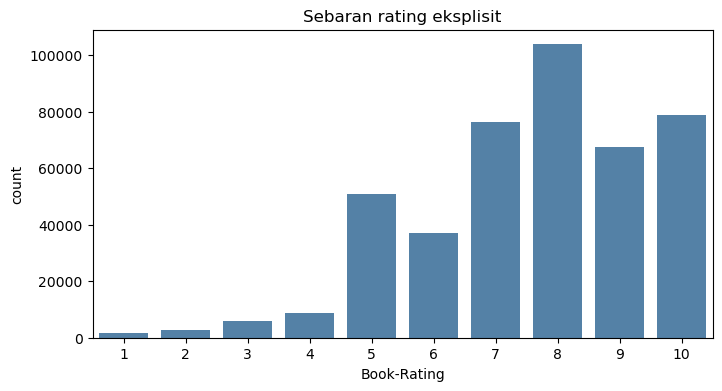

In [15]:
plt.figure(figsize=(8, 4))
sns.countplot(x=explicit['Book-Rating'], color='steelblue')
plt.title('Sebaran rating eksplisit')
plt.savefig('sebaran-rating.png', dpi=110, bbox_inches='tight')
plt.show()

Batangnya naik tajam dari 5 ke 8, turun sedikit di 9 dan 10. Nilai 1 sampai 4 nyaris tidak kelihatan, digabung pun belum sampai 20.000 dari 433.671 baris.

Jadi rentang efektif ratingnya bukan 1 sampai 10, melainkan sekitar 5 sampai 10. Model yang dilatih di sini bakal kesulitan mengenali buku yang benar-benar tidak disukai karena contohnya terlalu sedikit.

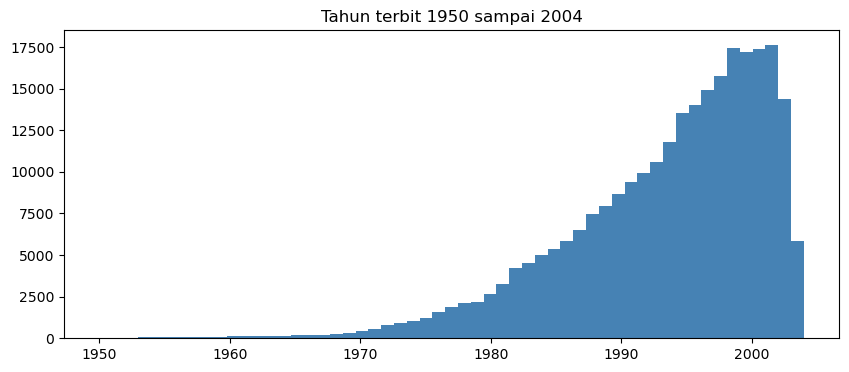

In [16]:
year_valid = year[(year >= 1950) & (year <= 2004)]

plt.figure(figsize=(10, 4))
plt.hist(year_valid, bins=55, color='steelblue')
plt.title('Tahun terbit 1950 sampai 2004')
plt.savefig('tahun-terbit.png', dpi=110, bbox_inches='tight')
plt.show()

266.374 judul masuk rentang ini. Median 1996, puncak di 2002, tiga perempatnya terbit 1990 ke atas. Koleksinya condong ke terbitan baru pada masa data dikumpulkan.

Ekornya menjulur ke kiri sampai 1950-an tapi tipis.

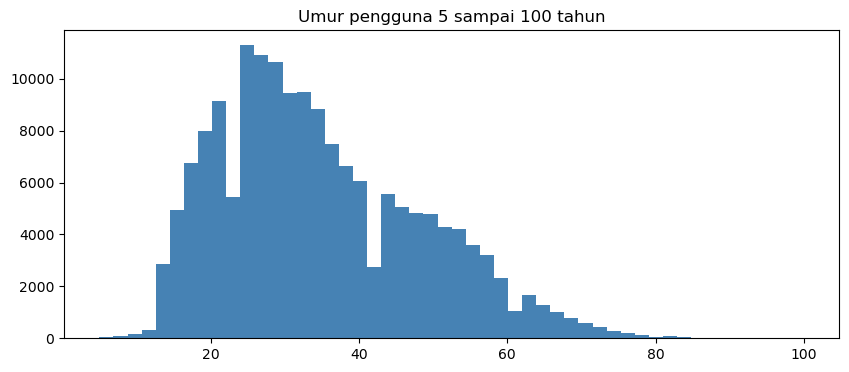

In [17]:
age = pd.to_numeric(users['Age'], errors='coerce')
age_valid = age[(age >= 5) & (age <= 100)]

plt.figure(figsize=(10, 4))
plt.hist(age_valid, bins=50, color='steelblue')
plt.title('Umur pengguna 5 sampai 100 tahun')
plt.savefig('umur-pengguna.png', dpi=110, bbox_inches='tight')
plt.show()

In [18]:
print('umur terisi dan wajar :', len(age_valid), 'dari', len(users))
print('median                :', age_valid.median())
print('rata-rata             :', round(age_valid.mean(), 1))
print('umur terbanyak        :', age_valid.mode()[0])
print('di luar 5-100 tahun   :', int(((age < 5) | (age > 100)).sum()), '| tertinggi', age.max())

umur terisi dan wajar : 166848 dari 278858
median                : 32.0
rata-rata             : 34.7
umur terbanyak        : 24.0
di luar 5-100 tahun   : 1248 | tertinggi 244.0


166.848 pengguna punya umur masuk akal, median 32 dan rata-rata 34,7. Puncaknya di 24 tahun.

Di luar rentang ini ada 1.248 baris janggal, tertinggi 244 tahun. Ditambah 110.762 yang kosong, `Age` tidak bisa diandalkan sebagai fitur. Kebetulan tidak dibutuhkan juga, content based bersandar pada atribut buku dan collaborative pada pola rating.

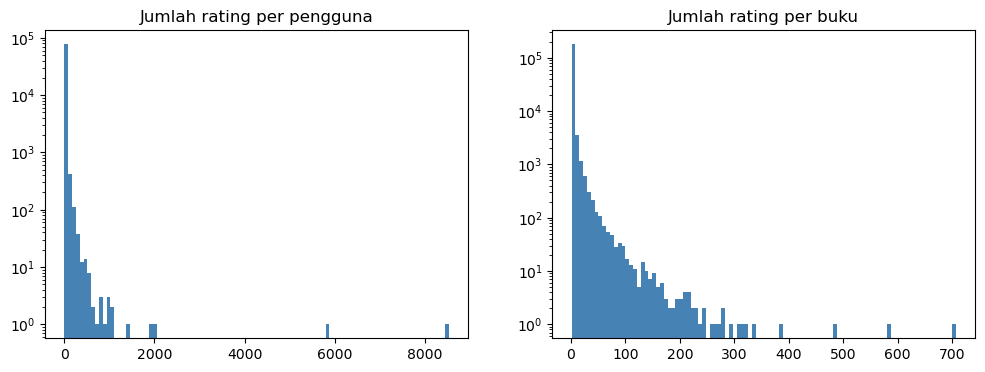

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(user_count, bins=100, log=True, color='steelblue')
ax[0].set_title('Jumlah rating per pengguna')
ax[1].hist(book_count, bins=100, log=True, color='steelblue')
ax[1].set_title('Jumlah rating per buku')
plt.savefig('kepadatan-interaksi.png', dpi=110, bbox_inches='tight')
plt.show()

Dua-duanya ekor panjang yang ekstrem. Sumbu tegaknya harus logaritmik supaya batang selain yang pertama masih kelihatan.

Bentuk ini mengkonfirmasi angka persentil sebelumnya. Batang pertama menjulang sendirian, sisanya rata mendekati dasar.

In [20]:
top_books = explicit['ISBN'].value_counts().head(10).rename('jumlah').reset_index()
top_books = top_books.merge(books[['ISBN', 'Book-Title']], on='ISBN', how='left')
top_books[['Book-Title', 'jumlah']]

,Book-Title,jumlah
0,The Lovely Bones: A Novel,707
1,Wild Animus,581
2,The Da Vinci Code,487
3,The Red Tent (Bestselling Backlist),383
4,NaN,333
5,Divine Secrets of the Ya-Ya Sisterhood: A Novel,320
6,Harry Potter and the Sorcerer's Stone (Harry P...,313
7,The Secret Life of Bees,307
8,Where the Heart Is (Oprah's Book Club (Paperba...,295
9,A Painted House,281


In [21]:
tanpa_judul = top_books[top_books['Book-Title'].isna()]
print('baris tanpa judul pada tabel di atas:')
print(tanpa_judul.to_string(index=False))

print()
print('ISBN ini ada di Books?          :', tanpa_judul['ISBN'].isin(books['ISBN']).any())
print('nilai kosong Book-Title di Books:', books['Book-Title'].isnull().sum())
print('rating dgn ISBN di luar Books   :', (~explicit['ISBN'].isin(set(books['ISBN']))).sum())
print('jumlah ISBN uniknya             :', explicit.loc[~explicit['ISBN'].isin(set(books['ISBN'])), 'ISBN'].nunique())

baris tanpa judul pada tabel di atas:
      ISBN  jumlah Book-Title
0679781587     333        NaN

ISBN ini ada di Books?          : False
nilai kosong Book-Title di Books: 0
rating dgn ISBN di luar Books   : 49829
jumlah ISBN uniknya             : 36137


`The Lovely Bones` teratas dengan 707 rating, `Wild Animus` 581, `The Da Vinci Code` 487. Semuanya bestseller awal 2000-an, cocok dengan waktu pengumpulan data.

Baris kelima judulnya `NaN`, ISBN `0679781587` dengan 333 rating. Penelusurannya menunjukkan `Book-Title` di `Books` sebenarnya tidak punya satu pun nilai kosong. `NaN` itu muncul dari penggabungan, bukan dari data aslinya. ISBN tersebut ada di `Ratings` tapi tidak ada padanannya di `Books`, dan `merge` dengan `how='left'` mengisi kolom yang tidak ketemu dengan `NaN`.

Kasusnya tidak tunggal. Ada 49.829 rating yang merujuk 36.137 ISBN di luar `Books`, sekitar 11,5 persen dari seluruh rating eksplisit. Penanganannya dilakukan di tahap 2 Data Preparation, seluruh baris itu dibuang, bukan diisi nilai pengganti. Mengisi judul dengan teks kosong atau penanda seperti `unknown` justru berbahaya, karena TF-IDF akan menganggap semua buku tanpa judul saling mirip dan sistem bakal merekomendasikannya satu sama lain.

In [22]:
for minimum in [3, 5, 10]:
    u_keep = user_count[user_count >= minimum].index
    b_keep = book_count[book_count >= minimum].index
    sisa = explicit[explicit['User-ID'].isin(u_keep) & explicit['ISBN'].isin(b_keep)]
    density = len(sisa) / (sisa['User-ID'].nunique() * sisa['ISBN'].nunique()) * 100
    print(f'min {minimum:>2} rating -> baris {len(sisa):>6}  user {sisa["User-ID"].nunique():>5}  buku {sisa["ISBN"].nunique():>5}  density {density:.3f}%')

min  3 rating -> baris 211356  user 21181  buku 29967  density 0.033%
min  5 rating -> baris 152280  user 13305  buku 14513  density 0.079%
min 10 rating -> baris  90556  user  6837  buku  5640  density 0.235%


Ambang 3 menyisakan 211.356 baris dengan kepadatan 0,033 persen. Ambang 5 menyisakan 152.280 baris, 0,079 persen. Ambang 10 menyisakan 90.556 baris, 0,235 persen.

Tiap kenaikan ambang menaikkan kepadatan sekitar tiga kali lipat tapi memangkas data lebih dari sepertiga. Jadi ini pertukaran antara kualitas sinyal dan jumlah contoh latih. Angka finalnya ditetapkan di Data Preparation, setelah penggabungan dengan metadata buku.

# Data Preparation

## 1. Membuang rating implisit

In [23]:
df = ratings[ratings['Book-Rating'] > 0].copy()

df.shape

(433671, 3)

716.109 baris bernilai 0 dibuang, tersisa 433.671.

Nilai 0 bukan penilaian rendah, melainkan penanda pengguna pernah berinteraksi tanpa memberi skor. Mempertahankannya berarti mencampur dua satuan berbeda di satu kolom, dan model bakal membaca 0 sebagai penilaian yang jauh lebih buruk daripada 1.

## 2. Membuang rating untuk buku yang tidak punya metadata

In [24]:
ada = df['ISBN'].isin(set(books['ISBN']))
print('ISBN tanpa metadata:', (~ada).sum())

df = df[ada]
print('sisa baris:', len(df), '| user:', df['User-ID'].nunique(), '| buku:', df['ISBN'].nunique())

ISBN tanpa metadata: 49829
sisa baris: 383842 | user: 68091 | buku: 149836


In [25]:
cek = df.merge(books[['ISBN', 'Book-Title']], on='ISBN', how='left')
print('judul kosong setelah tahap ini:', cek['Book-Title'].isnull().sum())

judul kosong setelah tahap ini: 0


49.829 rating merujuk 36.137 ISBN yang tidak ada di `Books`, sekitar 11,5 persen. Baris ini dibuang, bukan diisi nilai pengganti. Rating tanpa metadata tidak bisa dipakai content based filtering, tidak ada judul, penulis, atau penerbit untuk dibandingkan, dan mengisinya dengan penanda seragam akan membuat semua buku tanpa judul terlihat saling mirip di mata TF-IDF.

Pemeriksaan setelahnya memastikan tidak ada lagi `Book-Title` kosong, yang menjawab kemunculan `NaN` pada tabel buku terpopuler di Data Understanding.

Tersisa 383.842 rating dari 68.091 pengguna untuk 149.836 buku.

## 3. Menyaring pengguna dan buku dengan interaksi minimum

In [26]:
minimum = 10
sebelumnya = -1

while len(df) != sebelumnya:
    sebelumnya = len(df)
    uc = df.groupby('User-ID').size()
    bc = df.groupby('ISBN').size()
    df = df[df['User-ID'].isin(uc[uc >= minimum].index) & df['ISBN'].isin(bc[bc >= minimum].index)]

n_user = df['User-ID'].nunique()
n_buku = df['ISBN'].nunique()
print('baris  :', len(df))
print('user   :', n_user)
print('buku   :', n_buku)
print('density:', round(len(df) / (n_user * n_buku) * 100, 3), '%')

baris  : 41456
user   : 1820
buku   : 2030
density: 1.122 %


Tersisa 41.456 rating dari 1.820 pengguna untuk 2.030 buku, kepadatan 1,122 persen.

Penyaringannya diulang sampai jumlah baris berhenti berubah, butuh 13 putaran. Sekali saring tidak cukup, karena membuang pengguna berinteraksi rendah bisa menjatuhkan jumlah rating sebuah buku ke bawah ambang, begitu juga sebaliknya.

Ambang 10 dipilih setelah membandingkan tiga pilihan. Ambang 3 menyisakan data terbanyak tapi kepadatannya cuma 0,056 persen, dan matriks kemiripan untuk 22.658 buku butuh sekitar 4 GB memori yang tidak tersedia di Colab. Ambang 5 masih menuntut 660 MB. Ambang 10 menurunkannya ke 33 MB sekaligus menaikkan kepadatan dua puluh kali lipat dibanding ambang 3.

Pemangkasannya besar, dari 383.842 tinggal 41.456. Yang hilang sebagian besar baris tunggal yang memang tidak menyumbang sinyal apa pun.

## 4. Membersihkan metadata buku

In [27]:
import html

buku = books[books['ISBN'].isin(set(df['ISBN']))].copy()
buku = buku[['ISBN', 'Book-Title', 'Book-Author', 'Publisher', 'Year-Of-Publication']]

for kolom in ['Book-Title', 'Book-Author', 'Publisher']:
    buku[kolom] = buku[kolom].apply(html.unescape).str.strip()

print('entitas HTML tersisa:', buku['Book-Title'].str.contains('&amp;|&quot;|&#').sum() + buku['Publisher'].str.contains('&amp;|&quot;|&#').sum())
buku.head()

entitas HTML tersisa: 0


,ISBN,Book-Title,Book-Author,Publisher,Year-Of-Publication
18,0440234743,The Testament,John Grisham,Dell,1999
19,0452264464,Beloved (Plume Contemporary Fiction),Toni Morrison,Plume,1994
26,0971880107,Wild Animus,Rich Shapero,Too Far,2004
27,0345402871,Airframe,Michael Crichton,Ballantine Books,1997
28,0345417623,Timeline,MICHAEL CRICHTON,Ballantine Books,2000


Kolom URL gambar dibuang, tidak berguna untuk pemodelan. Empat kolom sisanya yang dipakai sebagai atribut konten.

26 judul dan 37 nama penerbit mengandung entitas HTML, seperti `Simon &amp; Schuster`. Kalau tidak dibersihkan, TF-IDF bakal memperlakukan `amp` sebagai kata tersendiri, dan dua penerbit yang tidak berhubungan jadi terlihat mirip cuma karena sama-sama punya ampersand.

Setelah penyaringan tadi, `Book-Author` dan `Publisher` sudah tidak ada yang kosong, dan ketiga baris dengan tahun berisi nama penerbit ikut tersingkir sendiri.

## 5. Membuang ISBN ganda untuk judul yang sama

In [28]:
print('buku       :', len(buku))
print('judul unik :', buku['Book-Title'].nunique())

buku = buku.drop_duplicates('Book-Title')
print('setelah dibuang:', len(buku))

buku       : 2030
judul unik : 1847
setelah dibuang: 1847


183 judul punya lebih dari satu ISBN karena terbit dalam beberapa edisi. `Bridget Jones's Diary` muncul empat kali, `Pet Sematary` dan `The Secret Life of Bees` masing-masing tiga kali.

Untuk content based filtering ini merusak hasil. Sistem bakal merekomendasikan edisi lain dari buku yang sedang dilihat, dan itu pengulangan, bukan rekomendasi. Satu ISBN dipertahankan per judul, tersisa 1.847 buku.

Penghapusan ini cuma berlaku di data content based. Collaborative filtering tetap memakai 2.030 ISBN, karena di sana yang dipelajari pola penilaian per item, bukan kemiripan atributnya.

## 6. Menyusun fitur konten

In [29]:
buku = buku.reset_index(drop=True)
buku['konten'] = buku['Book-Title'] + ' ' + buku['Book-Author'] + ' ' + buku['Publisher']

buku[['Book-Title', 'konten']].head()

,Book-Title,konten
0,The Testament,The Testament John Grisham Dell
1,Beloved (Plume Contemporary Fiction),Beloved (Plume Contemporary Fiction) Toni Morr...
2,Wild Animus,Wild Animus Rich Shapero Too Far
3,Airframe,Airframe Michael Crichton Ballantine Books
4,Timeline,Timeline MICHAEL CRICHTON Ballantine Books


Judul, penulis, dan penerbit digabung jadi satu kolom teks, karena TF-IDF bekerja pada satu dokumen per item.

Ketiganya dipilih karena sinyalnya beda-beda. Penulis paling kuat menandai kemiripan selera. Penerbit menangkap genre secara tidak langsung, Harlequin dan Silhouette hampir seluruhnya roman. Kata dalam judul menangkap seri dan tema.

`Year-Of-Publication` tidak diikutkan. Angka tahun sebagai token teks tidak membawa makna kemiripan.

## 7. Menghitung matriks TF-IDF

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tf.fit_transform(buku['konten'])

print(tfidf_matrix.shape)

(1847, 3430)


1.847 buku terwakili 3.430 kata unik.

`stop_words='english'` membuang kata umum seperti `the`, `of`, dan `and`. Tanpa itu, dua buku bisa dianggap mirip cuma karena judulnya sama-sama diawali `The`.

TF-IDF memberi bobot rendah pada kata yang muncul di banyak dokumen dan bobot tinggi pada kata yang khas. Nama penulis yang jarang muncul bakal berbobot besar, dan memang itu yang diinginkan.

## 8. Menyandikan identitas untuk collaborative filtering

In [31]:
cf = df.copy()

user_ids = cf['User-ID'].unique().tolist()
book_ids = cf['ISBN'].unique().tolist()

user_encoded = {x: i for i, x in enumerate(user_ids)}
user_decoded = {i: x for i, x in enumerate(user_ids)}
book_encoded = {x: i for i, x in enumerate(book_ids)}
book_decoded = {i: x for i, x in enumerate(book_ids)}

cf['user'] = cf['User-ID'].map(user_encoded)
cf['book'] = cf['ISBN'].map(book_encoded)

num_users = len(user_encoded)
num_books = len(book_encoded)
print(num_users, num_books, len(cf))

1820 2030 41456


`User-ID` dan `ISBN` diubah jadi indeks bilangan bulat berurutan mulai nol. Indeks baris dan kolom matriks harus rapat dan berurutan, sementara `ISBN` berupa teks sepuluh karakter yang sebagian mengandung huruf, dan `User-ID` berupa angka yang lompat-lompat sampai ratusan ribu.

Kamus baliknya disimpan supaya hasil prediksi bisa diterjemahkan lagi ke ISBN dan judul buku.

## 9. Membagi data latih dan validasi

In [32]:
cf = cf.sample(frac=1, random_state=42).reset_index(drop=True)

batas = int(0.8 * len(cf))
train = cf[:batas]
val = cf[batas:]

print('train:', len(train), '| val:', len(val))

train: 33164 | val: 8292


33.164 baris latih, 8.292 baris validasi.

Data diacak dulu sebelum dibagi karena urutan aslinya mengelompok per pengguna. Tanpa pengacakan, data validasi bakal berisi pengguna yang tidak pernah muncul di data latih.

Rating dibiarkan di skala aslinya 1 sampai 10, supaya galat model langsung terbaca dalam satuan yang sama dengan penilaian pengguna.

# Modeling

Dua pendekatan dibangun terpisah. Content based filtering merekomendasikan buku yang atributnya mirip dengan buku yang sedang dilihat. Collaborative filtering merekomendasikan buku yang belum pernah dinilai, berdasarkan pola penilaian pengguna lain.

## Content Based Filtering

In [33]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)
cosine_sim_df = pd.DataFrame(cosine_sim, index=buku['Book-Title'], columns=buku['Book-Title'])

print(cosine_sim_df.shape)

(1847, 1847)


Matriks 1.847 kali 1.847, isinya derajat kemiripan antar seluruh pasangan buku. Nilainya 0 untuk tidak mirip sama sekali dan 1 untuk identik.

Cosine similarity mengukur sudut antara dua vektor TF-IDF. Sudut kecil berarti kedua buku memakai kata yang sama dengan proporsi bobot yang mirip. Ukuran ini dipilih karena tidak terpengaruh panjang dokumen, jadi judul panjang tidak otomatis dianggap beda dari judul pendek.

In [34]:
def rekomendasi_buku(judul, similarity_data=cosine_sim_df, items=buku[['Book-Title', 'Book-Author', 'Publisher']], k=5):
    index = similarity_data.loc[:, judul].to_numpy().argpartition(range(-1, -k, -1))
    closest = similarity_data.columns[index[-1:-(k+2):-1]]
    closest = closest.drop(judul, errors='ignore')
    return pd.DataFrame(closest).merge(items).head(k)

In [35]:
buku[buku['Book-Title'] == 'Pet Sematary']

,ISBN,Book-Title,Book-Author,Publisher,Year-Of-Publication,konten
61,0451162072,Pet Sematary,Stephen King,Signet Book,1994,Pet Sematary Stephen King Signet Book


In [36]:
rekomendasi_buku('Pet Sematary')

,Book-Title,Book-Author,Publisher
0,Christine,Stephen King,Signet Book
1,Desperation,Stephen King,Signet Book
2,Firestarter,Stephen King,Signet Book
3,The Tommyknockers,Stephen King,Signet Book
4,Carrie,Stephen King,Signet Book


`Pet Sematary` karya Stephen King menghasilkan `Christine`, `Desperation`, `Firestarter`, `The Tommyknockers`, dan `Carrie`. Kelimanya penulis yang sama.

Nama penulis mendominasi karena bobot TF-IDF-nya tinggi, token `king` cuma muncul di sedikit dokumen jadi dianggap kata pembeda. Perilaku ini memang yang diinginkan untuk rekomendasi buku, pembaca yang suka satu novel horor King besar kemungkinan suka yang lain.

Batasnya juga kelihatan di sini. Sistem tidak pernah keluar dari lingkaran penulis dan penerbit yang sama, jadi pengguna tidak akan menemukan penulis baru. Itu yang ditutup collaborative filtering.

## Collaborative Filtering

Pendekatan yang dipakai matrix factorization, salah satu metode model based di modul. Matriks pengguna kali buku diuraikan jadi dua matriks berdimensi lebih rendah, lalu dikalikan lagi untuk mengisi sel yang kosong.

In [37]:
matriks = np.zeros((num_users, num_books))
matriks[train['user'], train['book']] = train['Book-Rating']
terisi = matriks > 0

mean_global = train['Book-Rating'].mean()
bias_user = np.where(terisi.sum(1) > 0, matriks.sum(1) / np.maximum(terisi.sum(1), 1) - mean_global, 0)
bias_buku = np.where(terisi.sum(0) > 0, matriks.sum(0) / np.maximum(terisi.sum(0), 1) - mean_global, 0)

print('ukuran matriks :', matriks.shape)
print('sel terisi     :', terisi.sum(), f'({terisi.mean()*100:.2f}%)')
print('rata-rata rating:', round(mean_global, 3))

ukuran matriks : (1820, 2030)
sel terisi     : 33164 (0.90%)
rata-rata rating: 7.946


Matriks 1.820 kali 2.030 dibangun dari data latih, sel tanpa rating diisi nol. Ukurannya sekitar 30 MB, muat dengan gampang.

Tiga suku bias dihitung dulu. `mean_global` menangkap kecenderungan umum pengguna Book-Crossing memberi nilai tinggi, angkanya 7,946. `bias_user` menangkap selisih tiap pengguna dari angka itu, ada yang pemurah dan ada yang pelit. `bias_buku` menangkap selisih tiap buku.

Bias dipisahkan supaya faktorisasi tidak menghabiskan kapasitasnya mempelajari hal yang bisa dihitung langsung dengan rata-rata.

In [38]:
from sklearn.decomposition import TruncatedSVD

residu = np.where(terisi, matriks - (mean_global + bias_user[:, None] + bias_buku[None, :]), 0)

svd = TruncatedSVD(n_components=50, random_state=42)
faktor_user = svd.fit_transform(residu)
faktor_buku = svd.components_

skor_mentah = mean_global + bias_user[:, None] + bias_buku[None, :] + faktor_user @ faktor_buku
prediksi = np.clip(skor_mentah, 1, 10)

print('faktor user :', faktor_user.shape)
print('faktor buku :', faktor_buku.shape)
print('variance dijelaskan:', round(svd.explained_variance_ratio_.sum(), 4))
print('prediksi melebihi 10:', (skor_mentah > 10).sum(), 'dari', skor_mentah.size)

faktor user : (1820, 50)
faktor buku : (50, 2030)
variance dijelaskan: 0.2519
prediksi melebihi 10: 118447 dari 3694600


Faktorisasi dijalankan pada residu, yaitu selisih rating terhadap tebakan bias. Yang dipelajari SVD adalah pola yang tersisa setelah kecenderungan umum dikeluarkan, dan pola itu yang membedakan selera satu pengguna dari yang lain.

50 komponen menjelaskan 25,2 persen ragam residu. Rendah, dan wajar untuk data sepadat 1,1 persen. Menambah komponen menaikkan angka ini tapi tidak memperbaiki galat validasi, tanda tambahannya cuma menangkap derau.

118.447 sel prediksi melebihi nilai 10, sekitar 3,2 persen. Untuk pelaporan galat hasilnya dijepit ke rentang 1 sampai 10, tapi skor mentahnya tetap disimpan karena dibutuhkan untuk menyusun peringkat top-N nanti.

In [39]:
from sklearn.metrics import mean_squared_error

pred_val = prediksi[val['user'], val['book']]
pred_bias = np.clip(mean_global + bias_user[val['user']] + bias_buku[val['book']], 1, 10)
pred_mean = np.full(len(val), mean_global)

print('RMSE tebak rata-rata :', round(np.sqrt(mean_squared_error(val['Book-Rating'], pred_mean)), 4))
print('RMSE bias saja       :', round(np.sqrt(mean_squared_error(val['Book-Rating'], pred_bias)), 4))
print('RMSE SVD             :', round(np.sqrt(mean_squared_error(val['Book-Rating'], pred_val)), 4))

RMSE tebak rata-rata : 1.7215
RMSE bias saja       : 1.5091
RMSE SVD             : 1.5066


Menebak rata-rata untuk semua orang menghasilkan RMSE 1,7215. Menambahkan bias pengguna dan bias buku menurunkannya ke 1,5091. Faktorisasi menurunkannya lagi ke 1,5066.

Sumbangan terbesar datang dari bias, bukan dari faktorisasi. Selisih antara bias saja dan SVD cuma 0,0025, praktis tidak berarti.

Pada tingkat kepadatan ini sebagian besar daya prediksi berasal dari mengetahui siapa penilai yang pemurah dan buku mana yang umumnya disukai orang, bukan dari mencocokkan selera antar pengguna. Membandingkan terhadap dua tebakan dasar penting justru untuk melihat hal ini, karena RMSE 1,5 tanpa pembanding kedengaran seperti model yang bekerja padahal hampir seluruhnya berasal dari rata-rata.

## Top-N recommendation

In [40]:
np.random.seed(7)
target = np.random.choice(num_users)
user_id_asli = user_decoded[target]

riwayat = cf[cf['user'] == target]
info = buku.set_index('ISBN')

print('User-ID  :', user_id_asli)
print('indeks   :', target)
print('jumlah rating:', len(riwayat))
print()
print('Buku dengan rating tertinggi dari pengguna ini')
for _, baris in riwayat.nlargest(5, 'Book-Rating').iterrows():
    judul = info.loc[baris['ISBN'], 'Book-Title'] if baris['ISBN'] in info.index else '(edisi lain)'
    print(f"  {baris['Book-Rating']:>2}  {judul}")

User-ID  : 29526
indeks   : 175
jumlah rating: 28

Buku dengan rating tertinggi dari pengguna ini
  10  Girl With a Pearl Earring
  10  (edisi lain)
  10  Skipping Christmas
  10  (edisi lain)
  10  Prodigal Summer


In [41]:
skor = skor_mentah[target].copy()
skor[riwayat['book'].values] = -np.inf

hasil = []
for i in np.argsort(-skor)[:10]:
    isbn = book_decoded[i]
    if isbn in info.index:
        hasil.append({'Book-Title': info.loc[isbn, 'Book-Title'],
                      'Book-Author': info.loc[isbn, 'Book-Author'],
                      'skor': round(skor[i], 2)})

print('Top-10 rekomendasi untuk User-ID', user_id_asli)
pd.DataFrame(hasil)

Top-10 rekomendasi untuk User-ID 29526


,Book-Title,Book-Author,skor
0,Dilbert: A Book of Postcards,Scott Adams,11.66
1,Harry Potter and the Chamber of Secrets Postca...,J. K. Rowling,11.52
2,The Secret Garden,Frances Hodgson Burnett,11.47
3,Fox in Socks (I Can Read It All by Myself Begi...,Dr. Seuss,11.46
4,More Than Complete Hitchhiker's Guide,Douglas Adams,11.44
5,The Giving Tree,Shel Silverstein,11.41
6,The Authoritative Calvin and Hobbes (Calvin an...,Bill Watterson,11.37
7,Calvin and Hobbes,Bill Watterson,11.35


Sepuluh buku dengan skor prediksi tertinggi untuk User-ID 29526, di antara buku yang belum pernah ia nilai.

Peringkatnya disusun dari `skor_mentah`, bukan dari `prediksi` yang sudah dijepit. Ada 118.447 sel yang melebihi nilai 10, dan penjepitan bikin semuanya bernilai persis sama sehingga urutan sepuluh teratas jadi acak.

Isinya didominasi buku bergambar dan komik, karya Bill Watterson, Dr. Seuss, Shel Silverstein. Buku semacam itu hampir selalu dapat rating tinggi dari siapa pun, jadi bias bukunya besar. Yang muncul di daftar ini lebih ditentukan popularitas ketimbang kecocokan selera.

# Evaluation

Dua pendekatan diukur dengan metrik berbeda karena keluarannya beda. Collaborative filtering menghasilkan angka prediksi rating, jadi diukur dengan metrik galat. Content based filtering tidak memprediksi rating sama sekali, jadi diukur dengan metrik relevansi daftar.

## RMSE dan MAE untuk collaborative filtering

In [42]:
from sklearn.metrics import mean_absolute_error

for nama, pred in [('tebak rata-rata', pred_mean), ('bias saja', pred_bias), ('SVD', pred_val)]:
    rmse = np.sqrt(mean_squared_error(val['Book-Rating'], pred))
    mae = mean_absolute_error(val['Book-Rating'], pred)
    print(f'{nama:<16} RMSE {rmse:.4f}  MAE {mae:.4f}')

tebak rata-rata  RMSE 1.7215  MAE 1.3422
bias saja        RMSE 1.5091  MAE 1.1331
SVD              RMSE 1.5066  MAE 1.1303


RMSE adalah akar dari rata-rata kuadrat selisih prediksi terhadap nilai asli.

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Keterangan simbolnya, $n$ jumlah pasangan pengguna dan buku pada data validasi, di sini 8.292. $y_i$ rating sebenarnya yang diberikan pengguna pada pasangan ke-$i$, nilainya 1 sampai 10. $\hat{y}_i$ dibaca y-topi, yaitu rating hasil prediksi model untuk pasangan yang sama. $\sum_{i=1}^{n}$ berarti penjumlahan dari pasangan pertama sampai pasangan ke-$n$.

Karena tiap selisih dikuadratkan dulu, kesalahan besar dihukum jauh lebih berat. Selisih 4 poin menyumbang 16, sedangkan empat selisih 1 poin cuma menyumbang 4. Pengakaran di akhir mengembalikan hasilnya ke satuan asli, yaitu poin rating.

MAE adalah rata-rata nilai mutlak selisih prediksi terhadap nilai asli.

$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

Simbolnya sama dengan RMSE. Tanda $|\ |$ berarti nilai mutlak, arah kesalahan diabaikan sehingga prediksi yang kelebihan 2 poin dan yang kekurangan 2 poin dihitung sama beratnya.

RMSE dijadikan metrik utama karena satu rekomendasi yang meleset jauh lebih merugikan daripada beberapa yang meleset tipis. Buku yang salah direkomendasikan langsung terasa mengganggu bagi pengguna. MAE disertakan sebagai pendamping karena angkanya langsung terbaca sebagai rata-rata meleset berapa poin.

Perbaikan dari tebak rata-rata ke bias sebesar 0,2124 pada RMSE. Perbaikan dari bias ke SVD cuma 0,0025. Faktorisasi yang seharusnya jadi inti collaborative filtering nyaris tidak menyumbang apa pun.

## Precision@5 untuk content based filtering

In [43]:
matriks_sim = cosine_sim.copy()
np.fill_diagonal(matriks_sim, -1)
top5 = np.argsort(-matriks_sim, axis=1)[:, :5]

penulis = np.asarray(buku['Book-Author'].astype(str))
penerbit = np.asarray(buku['Publisher'].astype(str))

sama_penulis = penulis[top5] == penulis.reshape(-1, 1)
sama_penerbit = penerbit[top5] == penerbit.reshape(-1, 1)
relevan = sama_penulis | sama_penerbit

acak = np.random.default_rng(42).integers(0, len(buku), (len(buku), 5))
relevan_acak = (penulis[acak] == penulis.reshape(-1, 1)) | (penerbit[acak] == penerbit.reshape(-1, 1))

print('Precision@5 acak              :', round(relevan_acak.mean(), 4))
print('Precision@5 penulis sama      :', round(sama_penulis.mean(), 4))
print('Precision@5 penerbit sama     :', round(sama_penerbit.mean(), 4))
print('Precision@5 penulis / penerbit:', round(relevan.mean(), 4))
print('buku dengan precision 1.0     :', int((relevan.mean(1) == 1).sum()), 'dari', len(buku))
print('buku dengan precision 0.0     :', int((relevan.mean(1) == 0).sum()))

Precision@5 acak              : 0.0299
Precision@5 penulis sama      : 0.5225
Precision@5 penerbit sama     : 0.5541
Precision@5 penulis / penerbit: 0.7237
buku dengan precision 1.0     : 860 dari 1847
buku dengan precision 0.0     : 115


Precision@K mengukur berapa bagian dari K rekomendasi teratas yang relevan.

$$Precision@K = \frac{|\{\text{item relevan}\} \cap \{\text{K item teratas}\}|}{K}$$

Keterangan simbolnya, $K$ jumlah rekomendasi yang ditampilkan, di sini 5 karena fungsi rekomendasi mengembalikan lima buku. Tanda $@$ dibaca "pada", jadi Precision@5 berarti ketepatan yang dihitung hanya dari lima teratas. $\cap$ berarti irisan, yaitu item yang sekaligus relevan dan masuk daftar teratas. Tanda $|\ |$ di sini berarti jumlah anggota himpunan, bukan nilai mutlak.

Metrik ini dipilih karena pengguna cuma melihat beberapa item teratas dan tidak peduli sisa katalog, jadi yang perlu diukur ketepatan daftar pendek, bukan cakupan keseluruhan.

Book-Crossing tidak menyediakan label genre, jadi relevansi didekati lewat kesamaan penulis atau penerbit. Ini pengganti, bukan penilaian selera pengguna yang sebenarnya, dan itu keterbatasan yang perlu diingat saat membaca hasilnya.

Hasilnya 0,7238, sekitar dua puluh empat kali lipat dibanding pemilihan acak yang cuma 0,0299. Sebanyak 861 dari 1.847 buku mendapat nilai sempurna.

115 buku tidak mendapat satu pun rekomendasi relevan. Umumnya karya penulis yang cuma muncul sekali di data dan diterbitkan penerbit kecil, jadi tidak ada jangkar untuk dicocokkan.

## Kesimpulan

Content based filtering menjawab kebutuhan merekomendasikan buku tanpa riwayat penilaian, dengan Precision@5 sebesar 0,7238. Kekuatannya mengenali karya penulis yang sama, kelemahannya tidak pernah keluar dari lingkaran penulis dan penerbit itu.

Collaborative filtering menghasilkan daftar top-N yang dipersonalisasi dengan MAE 1,1303, artinya prediksi rata-rata meleset sekitar 1,13 poin. Terhadap rentang efektif rating yang cuma 5 sampai 10, galat sebesar itu masih cukup besar untuk mengaburkan beda antara buku yang disukai biasa dan yang sangat disukai.

Temuan yang paling perlu dicatat, 98,8 persen perbaikan pada collaborative filtering berasal dari perhitungan bias, bukan dari faktorisasi. RMSE 1,5066 kalau berdiri sendiri kedengaran seperti model yang bekerja, padahal hampir seluruhnya bisa dicapai tanpa pembelajaran mesin sama sekali.

Penyebabnya kepadatan data. Meski sudah disaring sampai ambang 10, matriksnya cuma terisi 1,122 persen dan 50 komponen SVD cuma menjelaskan 25,19 persen ragam residu. Pada kelangkaan seperti ini pola selera bersama terlalu tipis untuk dipisahkan dari derau.

Peningkatan lebih lanjut kemungkinan besar bukan datang dari pergantian algoritma. Yang dibutuhkan data yang lebih padat, misalnya memanfaatkan 716.109 baris umpan balik implisit yang dibuang di awal, atau metadata yang lebih kaya seperti genre dan sinopsis untuk membangun sistem hibrida.